新しいデータセット

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import os
import re
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from scipy.stats import mode
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

#表情データの読み込みとデータフレームに格納
folder_path = Path('../../../filtered_face_data_0.95/')

file_list = folder_path.glob('*.csv')

file_path_list = [str(p) for p in file_list]

df = pd.DataFrame(file_path_list, columns=['filepath'])

files_df = df
files_df['filename'] = df['filepath'].apply(lambda p: Path(p).name)
files_df['ID'] = files_df['filename'].str.extract(r'ID(\d+)')
files_df['ID'] = files_df['ID'].astype(int)

#患者の疾患有無
labels_df = pd.read_csv(r"C:\Users\robotics\proj\Research\code\voice\delirium.csv")
#患者と疾患有無を結合
file_with_labels_df = pd.merge(files_df, labels_df, on='ID', how='left')
file_with_labels_df.drop(columns=['Sex'], inplace=True)

#print(file_with_labels_df.columns)

すべての区間（質問、応答のみ）での最大値

In [78]:
def all_max(file_path: list, data: pd.Series, file_lengths: list):
    df = pd.DataFrame()
    filenumber_df = pd.DataFrame()
    for f, a in zip(file_path, data):
        #ファイル読み込み、ファイル名切り出し
        df_file = pd.read_csv(f)
        current_filename = os.path.basename(f)
        #df_file = df_file.dropna(how='all', axis=1)
        
        df_file['Delirium'] = a
        df_file['filename'] = current_filename

        df_file['label'] = df_file['label'].astype(str).str.strip()
        
        #質問、応答部分のAUだけを抽出
        df_sort_df = df_file[df_file['label'].str.match(r'^(question|answer)(10|[1-9])$', na=False)]
        #print(df_sort_df)
        #フレーム数の特徴量を追加


        columns_to_extract = ["label"] + [col for col in df_sort_df.columns if col.startswith("AU")] + ["Delirium", "filename"]
        df_final_df = df_sort_df[columns_to_extract]

        #print(df_test_final_df)

        columns_to_AU = ["AU07", "AU11", "AU20"]

        #AU07, 11, 20の削除
        df_final_df = df_final_df.drop(columns=columns_to_AU, errors='ignore')
        #print(df_test_final_df)
        

        #数値型に変更
        #df_test_final_df['filename'] = pd.to_numeric(df_test_final_df['filename'], errors='coerce')
        #print(df_test_final_df)

        #質問ごとの平均値を計算
        #df_final_df['count'] = df_final_df.groupby('label')['label'].transform('size')
        df_final_df['filenumber'] = df_final_df['filename'].astype(str).str.extract(r'(\d+)').astype(float).astype(int)
        #print(df_final_df)
        #df_final_df = df_final_df.drop(columns=['filename_num'], errors='ignore')
        df_final_df['filename'] = pd.to_numeric(df_final_df['filename'], errors='coerce')
        #print(df_final_df)
        filenumber_df = df_final_df.groupby('label').mean()
        df_max_df = df_final_df.groupby('label').median()
        df_max_df['filenumber'] = filenumber_df['filenumber']
        df_max_df['Delirium'] = filenumber_df['Delirium']
        df_max_df = df_max_df.reset_index(drop=True)

        #print(df_max_df)
        
        file_lengths.append(len(df_max_df))

        df = pd.concat([df, df_max_df], ignore_index=True)
    
    #print(df)

    return file_lengths, df

質問区間での最大値

In [68]:
def question_max(file_path: list, data: pd.Series, file_lengths: list):
    df = pd.DataFrame()
    filenumber_df = pd.DataFrame()
    for f, a in zip(file_path, data):
        #ファイル読み込み、ファイル名切り出し
        df_file = pd.read_csv(f)
        current_filename = os.path.basename(f)
        #df_file = df_file.dropna(how='all', axis=1)
        
        df_file['Delirium'] = a
        df_file['filename'] = current_filename

        df_file['label'] = df_file['label'].astype(str).str.strip()
        
        #質問、応答部分のAUだけを抽出
        df_sort_df = df_file[df_file['label'].str.match(r'^(question)(10|[1-9])$', na=False)]
        #print(df_sort_df)
        #フレーム数の特徴量を追加


        columns_to_extract = ["label"] + [col for col in df_sort_df.columns if col.startswith("AU")] + ["Delirium", "filename"]
        df_final_df = df_sort_df[columns_to_extract]

        #print(df_test_final_df)

        columns_to_AU = ["AU07", "AU11", "AU20"]

        #AU07, 11, 20の削除
        df_final_df = df_final_df.drop(columns=columns_to_AU, errors='ignore')
        #print(df_test_final_df)
        

        #数値型に変更
        #df_test_final_df['filename'] = pd.to_numeric(df_test_final_df['filename'], errors='coerce')
        #print(df_test_final_df)

        #質問ごとの平均値を計算
        #df_final_df['count'] = df_final_df.groupby('label')['label'].transform('size')
        df_final_df['filenumber'] = df_final_df['filename'].astype(str).str.extract(r'(\d+)').astype(float).astype(int)
        #print(df_final_df)
        #df_final_df = df_final_df.drop(columns=['filename_num'], errors='ignore')
        df_final_df['filename'] = pd.to_numeric(df_final_df['filename'], errors='coerce')
        #print(df_final_df)
        filenumber_df = df_final_df.groupby('label').mean()
        df_max_df = df_final_df.groupby('label').median()
        df_max_df['filenumber'] = filenumber_df['filenumber']
        df_max_df['Delirium'] = filenumber_df['Delirium']
        df_max_df = df_max_df.reset_index(drop=True)

        #print(df_max_df)
        
        file_lengths.append(len(df_max_df))

        df = pd.concat([df, df_max_df], ignore_index=True)
    
    #print(df)

    return file_lengths, df

応答区間での最大値

In [117]:
def answer_max(file_path: list, data: pd.Series, file_lengths: list):
    df = pd.DataFrame()
    filenumber_df = pd.DataFrame()
    for f, a in zip(file_path, data):
        #ファイル読み込み、ファイル名切り出し
        df_file = pd.read_csv(f)
        current_filename = os.path.basename(f)
        #df_file = df_file.dropna(how='all', axis=1)
        
        df_file['Delirium'] = a
        df_file['filename'] = current_filename

        df_file['label'] = df_file['label'].astype(str).str.strip()
        
        #質問、応答部分のAUだけを抽出
        df_sort_df = df_file[df_file['label'].str.match(r'^(answer)(10|[1-9])$', na=False)]
        #print(df_sort_df)
        #フレーム数の特徴量を追加


        columns_to_extract = ["label"] + [col for col in df_sort_df.columns if col.startswith("AU")] + ["Delirium", "filename"]
        df_final_df = df_sort_df[columns_to_extract]

        #print(df_test_final_df)

        columns_to_AU = ["AU07", "AU11", "AU20"]

        #AU07, 11, 20の削除
        df_final_df = df_final_df.drop(columns=columns_to_AU, errors='ignore')
        #print(df_test_final_df)
        

        #数値型に変更
        #df_test_final_df['filename'] = pd.to_numeric(df_test_final_df['filename'], errors='coerce')
        #print(df_test_final_df)

        #質問ごとの平均値を計算
        #df_final_df['count'] = df_final_df.groupby('label')['label'].transform('size')
        df_final_df['filenumber'] = df_final_df['filename'].astype(str).str.extract(r'(\d+)').astype(float).astype(int)
        #print(df_final_df)
        #df_final_df = df_final_df.drop(columns=['filename_num'], errors='ignore')
        df_final_df['filename'] = pd.to_numeric(df_final_df['filename'], errors='coerce')
        #print(df_final_df)
        filenumber_df = df_final_df.groupby('label').mean()
        #ここを変更
        df_max_df = df_final_df.groupby('label').max() #.head(30).groupby('label')
        df_max_df['filenumber'] = filenumber_df['filenumber']
        df_max_df['Delirium'] = filenumber_df['Delirium']
        df_max_df = df_max_df.reset_index(drop=True)

        #print(df_max_df)
        
        file_lengths.append(len(df_max_df))

        df = pd.concat([df, df_max_df], ignore_index=True)
    
    #print(df)

    return file_lengths, df

質問区間の最大値と応答区間の最大値の差分

In [46]:
def diff_max(file_path: list, data: pd.Series, file_lengths: list):
    df = pd.DataFrame()
    filenumber_df = pd.DataFrame()
    filenumber_df1 = pd.DataFrame()
    for f, d in zip(file_path, data):
        #ファイル読み込み、ファイル名切り出し
        df_file = pd.read_csv(f)
        current_filename = os.path.basename(f)
        #df_file = df_file.dropna(how='all', axis=1)
        
        df_file['Delirium'] = d
        df_file['filename'] = current_filename

        df_file['label'] = df_file['label'].astype(str).str.strip()
        
        #質問、応答部分のAUだけを抽出
        df_sort_df = df_file[df_file['label'].str.match(r'^(answer)(10|[1-9])$', na=False)]
        df1_sort_df = df_file[df_file['label'].str.match(r'^(question)(10|[1-9])$', na=False)]
        #print(df_sort_df)
        #フレーム数の特徴量を追加


        columns_to_extract = ["label"] + [col for col in df_sort_df.columns if col.startswith("AU")] + ["Delirium", "filename"]
        df_final_df = df_sort_df[columns_to_extract]
        df1_final_df = df1_sort_df[columns_to_extract]

        #print(df_test_final_df)

        columns_to_AU = ["AU07", "AU11", "AU20", "AU01", "AU09", "AU14", "AU15", "AU23", "AU24", "AU26", "AU28", "AU43"]
        # , "AU04", "AU09", "AU12", "AU23", "AU26", "AU28" (max)


        #AU07, 11, 20の削除
        df_final_df = df_final_df.drop(columns=columns_to_AU, errors='ignore')
        df1_final_df = df1_final_df.drop(columns=columns_to_AU, errors='ignore')
        #print(df_test_final_df)
        

        #数値型に変更
        #df_test_final_df['filename'] = pd.to_numeric(df_test_final_df['filename'], errors='coerce')
        #print(df_test_final_df)

        #質問ごとの平均値を計算
        #df_final_df['count'] = df_final_df.groupby('label')['label'].transform('size')
        df_final_df['filenumber'] = df_final_df['filename'].astype(str).str.extract(r'(\d+)').astype(float).astype(int)
        df1_final_df['filenumber'] = df1_final_df['filename'].astype(str).str.extract(r'(\d+)').astype(float).astype(int)
        #print(df_final_df)
        #filename列は削除
        df_final_df = df_final_df.drop(columns=['filename'])
        df1_final_df = df1_final_df.drop(columns=['filename'])
        #print(df_final_df)

        df_final_df['label'] = df_final_df['label'].astype(str).str.extract(r'(\d+)').astype(float).astype(int)
        df1_final_df['label'] = df1_final_df['label'].astype(str).str.extract(r'(\d+)').astype(float).astype(int)
        #print(df_final_df)
        
        #df_final_df = df_final_df.drop(columns=['filename_num'], errors='ignore')
        #df_final_df['filename'] = pd.to_numeric(df_final_df['filename'], errors='coerce')
        #df1_final_df['filename'] = pd.to_numeric(df1_final_df['filename'], errors='coerce')
        #print(df_final_df)
        filenumber_df = df_final_df.groupby('label', as_index=False).mean()
        filenumber_df1 = df1_final_df.groupby('label', as_index=False).mean()
        #ここを変更
        df_max_df = df_final_df.groupby('label', as_index=False).mean()
        df1_max_df = df1_final_df.groupby('label', as_index=False).mean()
        #print(df_max_df)
        #print(df1_max_df)
        #print(filenumber_df)
        df_max_df['filenumber'] = filenumber_df['filenumber']
        df_max_df['Delirium'] = filenumber_df['Delirium']
        df_max_df = df_max_df.reset_index(drop=True)

        df1_max_df['filenumber'] = filenumber_df1['filenumber']
        df1_max_df['Delirium'] = filenumber_df1['Delirium']
        df1_max_df = df1_max_df.reset_index(drop=True)

        #print(df_max_df)
        
        #質問、応答区間でlabel数が異なる場合の処理
        if len(df_max_df) != len(df1_max_df):
            df1_max_df = df1_max_df[df1_max_df['label'].isin(df_max_df['label'])]
            df_max_df = df_max_df[df_max_df['label'].isin(df1_max_df['label'])]
            df1_max_df = df1_max_df.sort_values('label').reset_index(drop=True)
            df_max_df = df_max_df.sort_values('label').reset_index(drop=True)

        #print(df_max_df, df1_max_df)
        
        df_diff = df_max_df - df1_max_df

        df_diff['filenumber'] = filenumber_df['filenumber']
        df_diff['Delirium'] = filenumber_df['Delirium']

        #print(df_diff)

        df = pd.concat([df, df_diff], ignore_index=True)
        file_lengths.append(len(df_diff))
    
    #print(df)

    return file_lengths, df

PCA用のデータ読み込み、結合

In [26]:
def kernel_pca(file_path: list, data: pd.Series, file_lengths: list):
    df = pd.DataFrame()
    filenumber_df = pd.DataFrame()
    # filenumber_df1 = pd.DataFrame()
    for f, d in zip(file_path, data):
        #ファイル読み込み、ファイル名切り出し
        df_file = pd.read_csv(f)
        current_filename = os.path.basename(f)
        #df_file = df_file.dropna(how='all', axis=1)
        
        df_file['Delirium'] = d
        df_file['filename'] = current_filename

        df_file['label'] = df_file['label'].astype(str).str.strip()
        
        #質問、応答部分のAUだけを抽出
        df_sort_df = df_file[df_file['label'].str.match(r'^(answer)(10|[1-9])$', na=False)]
        # df1_sort_df = df_file[df_file['label'].str.match(r'^(question)(10|[1-9])$', na=False)]
        #print(df_sort_df)
        #フレーム数の特徴量を追加


        columns_to_extract = ["label"] + [col for col in df_sort_df.columns if col.startswith("AU")] + ["Delirium", "filename"]
        df_final_df = df_sort_df[columns_to_extract]
        # df1_final_df = df1_sort_df[columns_to_extract]

        #print(df_test_final_df)

        columns_to_AU = ["AU07", "AU11", "AU20"]

        #AU07, 11, 20の削除
        df_final_df = df_final_df.drop(columns=columns_to_AU, errors='ignore')
        # df1_final_df = df1_final_df.drop(columns=columns_to_AU, errors='ignore')
        #print(df_test_final_df)
        

        #数値型に変更
        #df_test_final_df['filename'] = pd.to_numeric(df_test_final_df['filename'], errors='coerce')
        #print(df_test_final_df)

        #質問ごとの平均値を計算
        #df_final_df['count'] = df_final_df.groupby('label')['label'].transform('size')
        df_final_df['filenumber'] = df_final_df['filename'].astype(str).str.extract(r'(\d+)').astype(float).astype(int)
        # df1_final_df['filenumber'] = df1_final_df['filename'].astype(str).str.extract(r'(\d+)').astype(float).astype(int)
        #print(df_final_df)
        #filename列は削除
        df_final_df = df_final_df.drop(columns=['filename'])
        # df1_final_df = df1_final_df.drop(columns=['filename'])
        #print(df_final_df)

        df_final_df['label'] = df_final_df['label'].astype(str).str.extract(r'(\d+)').astype(float).astype(int)
        # df1_final_df['label'] = df1_final_df['label'].astype(str).str.extract(r'(\d+)').astype(float).astype(int)
        #print(df_final_df)
        
        #df_final_df = df_final_df.drop(columns=['filename_num'], errors='ignore')
        #df_final_df['filename'] = pd.to_numeric(df_final_df['filename'], errors='coerce')
        #df1_final_df['filename'] = pd.to_numeric(df1_final_df['filename'], errors='coerce')
        #print(df_final_df)
        #filenumber_df = df_final_df.groupby('label', as_index=False).mean()
        # filenumber_df1 = df1_final_df.groupby('label', as_index=False).mean()
        #ここを変更
        df_pca_df = df_final_df.max(axis=0)
        df_pca_df = df_pca_df.to_frame().T
        # df1_max_df = df1_final_df.groupby('label', as_index=False).mean()
        #print(df_max_df)
        #print(df1_max_df)
        #print(filenumber_df)
        #df_final_df['filenumber'] = filenumber_df['filenumber']
        #df_final_df['Delirium'] = filenumber_df['Delirium']
        #df_pca_df = df_pca_df.reset_index(drop=True)

        # df1_max_df['filenumber'] = filenumber_df1['filenumber']
        # df1_max_df['Delirium'] = filenumber_df1['Delirium']
        # df1_max_df = df1_max_df.reset_index(drop=True)

        #print(df_max_df)
        
        #質問、応答区間でlabel数が異なる場合の処理
        # if len(df_max_df) != len(df1_max_df):
        #     df1_max_df = df1_max_df[df1_max_df['label'].isin(df_max_df['label'])]
        #     df_max_df = df_max_df[df_max_df['label'].isin(df1_max_df['label'])]
        #     df1_max_df = df1_max_df.sort_values('label').reset_index(drop=True)
        #     df_max_df = df_max_df.sort_values('label').reset_index(drop=True)

        # #print(df_max_df, df1_max_df)
        
        # df_diff = df_max_df - df1_max_df

        # df_diff['filenumber'] = filenumber_df['filenumber']
        # df_diff['Delirium'] = filenumber_df['Delirium']

        #print(df_diff)

        df = pd.concat([df, df_pca_df], ignore_index=True)
        file_lengths.append(len(df_pca_df))
    
    #print(df)

    return file_lengths, df

学習, 評価

In [47]:
#学習・テストデータとなるファイルの分割
X_files = file_with_labels_df.drop(columns='Delirum', errors='ignore')
#print(X_files)
y_labels = file_with_labels_df.drop(columns=['filepath', 'filename', 'ID'], errors='ignore')
#rint(y_labels)

#層化５分割交差検証
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_index, test_index) in enumerate(skf.split(X_files, y_labels)):
    X_train_sort, X_test_sort = X_files.iloc[train_index], X_files.iloc[test_index]
    y_train_sort, y_test_sort = y_labels.iloc[train_index], y_labels.iloc[test_index]

    train_file_path = [f for f in X_train_sort['filepath']]
    #print(type(train_file_path), type(y_train_sort['Delirium']))
    test_file_path = [f for f in X_test_sort['filepath']]
    train_df = pd.DataFrame()
    test_df = pd.DataFrame()
    train_file_lengths = []
    test_file_lengths = []
    #print(type(test_file_lengths))

    #学習データ
    train_file_lengths, train_df = diff_max(
        train_file_path,
        y_train_sort['Delirium'],
        train_file_lengths)
    #train_df['filenumber'] = train_df['filename'].astype(str).str.extract(r'(\d+)')
    #train_df = train_df.drop(columns=['filename'], errors='ignore')
    #print(train_df)
    #テストデータ
    test_file_lengths, test_df = diff_max(
        test_file_path,
        y_test_sort['Delirium'],
        test_file_lengths
    )

    #グリッドサーチのための学習・検証データの用意とテストデータの用意
    y_train_grid = train_df['Delirium']
    y_test_grid = test_df['Delirium']

    columns_to_delete = ['Delirium', 'label']
    columns_to_delete2 = ['Delirium', 'filenumber', 'label']

    X_train_grid = train_df.drop(columns=columns_to_delete, errors='ignore')
    X_test_grid = test_df.drop(columns=columns_to_delete2, errors='ignore')

    #print(X_train_grid)

    #患者ごとに分割するための変数を用意し、学習データからfilenumberを削除
    patient_groups = X_train_grid['filenumber'].values
    X_train_boruta = X_train_grid.drop(columns=['filenumber']).copy()

    #Add.------学習データだけを使用してBorutaを実行------

    # #Borutaの実行
    # Rf_boruta = RandomForestClassifier(n_jobs=-1, max_depth=5)
    # feat_selector = BorutaPy(Rf_boruta, n_estimators='auto', verbose=2, random_state=1)
    # feat_selector.fit(X_train_boruta, y_train_grid)
    # X_train_model = X_train_boruta.loc[:, feat_selector.support_]
    # X_test_model = X_test_grid.loc[:, feat_selector.support_]

    # #Borutaで採用、削除した特徴量の確認
    # feature_names = np.array(X_train_boruta.columns)
    # dropped_features = feature_names[~feat_selector.support_]
    # accepted_features = feature_names[feat_selector.support_]
    # tentative_features = feature_names[feat_selector.support_weak_]

    # print(f"削除前の特徴量数：{len(feature_names)}")
    # print(f"削除された特徴量数：{len(dropped_features)}")
    # print("削除された特徴量一覧")
    # print(dropped_features)

    #5.------学習の準備(学習器と学習方法の設定)------

    #モデル・グリッドサーチの定義
    model = RandomForestClassifier(random_state=42)
    cv = GroupKFold(n_splits=5, shuffle=True, random_state=42)
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 5, 10, 15],
        'min_samples_split': [2, 5, 10]
        }
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='accuracy', cv=cv, n_jobs=-1)

    #6.------グリッドサーチ------
    #print(X_train_grid)
    grid_search.fit(X_train_boruta, y_train_grid, groups=patient_groups)
    print(f"---fold{fold+1}---\n")
    print(f"最適なハイパーパラメータ：{grid_search.best_params_}")
    print(f"CVでのmax精度(Accuracy):{grid_search.best_score_:.4f}")

    #行と列の表示制限を解除（または十分に大きな値に設定）
    pd.set_option('display.max_rows', None)     # すべての行を表示
    pd.set_option('display.max_columns', None)  # すべての列を表示
    pd.set_option('display.width', 1000)        # 表示幅を広くする

    #結果をDataFrameに変換し表示
    results_df = pd.DataFrame(grid_search.cv_results_)

    print("--- グリッドサーチの全試行結果 ---")
    print(results_df)

    #表示設定を元に戻す (推奨)
    #グローバルな設定を元に戻し、他の処理に影響を与えないようにします
    pd.reset_option('display.max_rows')
    pd.reset_option('display.max_columns')
    pd.reset_option('display.width')


    #7.------テストデータでの性能評価------
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_grid)
    final_accuracy = accuracy_score(y_test_grid, y_pred)

    #print(f"テストデータでの正解率: {final_accuracy:.4}\n")
    #print(y_pred)

    print(test_file_lengths)

    file_predictions = []
    start_idx = 0
    for length in test_file_lengths:
        end_idx = start_idx + length
        predictions_for_this_file = y_pred[start_idx:end_idx]
        #print(start_idx, end_idx)
        majority_vote = mode(predictions_for_this_file)[0]
        #print(majority_vote)
        file_predictions.append([majority_vote, start_idx, end_idx])
        start_idx = end_idx

    first_column_list = [item[0] for item in file_predictions]

    #print(first_column_list)

    y_test_files = X_test_sort['Delirium'].values

    #print(type(y_test_files))

    y_test_files_copy = X_test_sort

    y_test_files_copy = y_test_files_copy.assign(Predictions=first_column_list)

    print("各テストファイルごとの分類結果\n")
    print(y_test_files_copy.drop(columns=['filepath'], errors='ignore'))

    correct_files = np.sum(np.array(first_column_list) == y_test_files)
    total_files = len(X_test_sort)
    file_accuracy = correct_files/ total_files

    scores = []
    scores.append(file_accuracy)
    print("\n")
    print(f"正解率 (ファイル単位): {file_accuracy:.4f} ({correct_files}/{total_files} ファイル正解)\n")


    #8.------混同行列の作成------
    cm = confusion_matrix(y_test_files, first_column_list)
    cm_df = pd.DataFrame(cm, 
                        index=['正解: 0', '正解: 1'], 
                        columns=['予測: 0', '予測: 1'])

    print("混同行列:")
    print(cm_df)
    print("\n") # 見やすいように改行

    #特徴量の重要度を取得
    feature_names = X_train_boruta.columns.tolist()
        
    importances = best_model.feature_importances_

    #特徴量の名前と重要度をまとめたDataFrameを作成
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    #重要度が高い順にソート
    sorted_importance_df = importance_df.sort_values(by='Importance', ascending=False)

    print(sorted_importance_df)

---fold1---

最適なハイパーパラメータ：{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
CVでのmax精度(Accuracy):0.5948
--- グリッドサーチの全試行結果 ---
    mean_fit_time  std_fit_time  mean_score_time  std_score_time param_max_depth  param_min_samples_split  param_n_estimators                                             params  split0_test_score  split1_test_score  split2_test_score  split3_test_score  split4_test_score  mean_test_score  std_test_score  rank_test_score
0        0.174997      0.005333         0.010878        0.000835            None                        2                  50  {'max_depth': None, 'min_samples_split': 2, 'n...           0.548387           0.627660           0.617021           0.560976           0.581081         0.587025        0.030847                6
1        0.342404      0.022293         0.014571        0.002591            None                        2                 100  {'max_depth': None, 'min_samples_split': 2, 'n...           0.559140           0.648936     

カーネルPCA

2


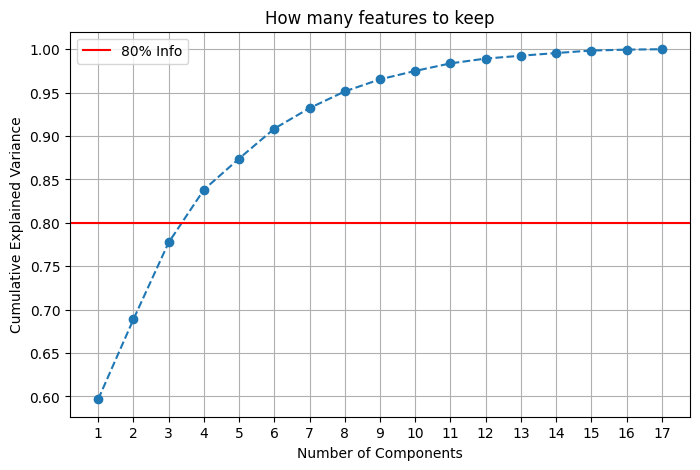

In [ ]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

X_files = file_with_labels_df.drop(columns='Delirum', errors='ignore')
#print(X_files)
y_labels = file_with_labels_df.drop(columns=['filepath', 'filename', 'ID'], errors='ignore')

X_train, X_test, y_train, y_test = train_test_split(X_files, y_labels, test_size=0.2, random_state=42)
#print(X_train)

train_file_path = [f for f in X_train['filepath']]
#print(train_file_path)
test_file_path = [f for f in X_test['filepath']]

train_df = pd.DataFrame()
test_df = pd.DataFrame()
train_file_lengths = []
test_file_lengths = []

train_file_lengths, train_df = kernel_pca(
    train_file_path,
    y_train['Delirium'],
    train_file_lengths
    )

print(train_df.ndim)

test_file_lengths, test_df = kernel_pca(
    test_file_path,
    y_test['Delirium'],
    test_file_lengths
    )

columns = ['label', 'Delirium', 'filenumber']
train_df = train_df.drop(columns=columns, errors='ignore')
test_df = test_df.drop(columns=columns, errors='ignore')

pca = PCA()
pca.fit(train_df)

# 累積寄与率（各成分を足していくと、元の情報の何割をカバーできるか）を計算
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# --- 判断用の可視化 ---
plt.figure(figsize=(8, 5))
plt.plot(range(1, 18), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.8, color='r', linestyle='-', label='80% Info') # 情報の8割保持ライン
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('How many features to keep')
plt.xticks(range(1, 18))
plt.legend()
plt.grid(True)
plt.show()

# 3. 実際に目標の次元数（例：3次元）に削減して保存する
# 上記のグラフを見て、8割〜9割を超えたあたりの次元数を選ぶのが一般的です
target_dim = 4
pca_final = PCA(n_components=target_dim)
X_reduced = pca_final.fit_transform(train_df)



In [49]:
print(X_reduced.shape)

print(y_train.shape)


(48, 4)
(48, 1)


In [37]:
from sklearn.decomposition import KernelPCA

# カーネルPCAの実行 (rbfカーネルは非線形構造に強い)
# n_components: 削減後の次元数
# fit_inverse_transform: 元に戻す計算が必要な場合はTrue
kpca = KernelPCA(n_components=3, kernel='rbf', gamma=0.1, fit_inverse_transform=True)
X_kpca = kpca.fit_transform(train_df)

print(X_kpca)

print(f"KPCA後の形状: {X_kpca.shape}")

[[ 3.23062245e-01  4.48725028e-02  1.07993887e-02]
 [ 2.43481740e-01 -1.00750322e-02 -4.35175063e-02]
 [ 1.93336869e-01  1.84575179e-02 -1.13555542e-02]
 [-1.15376051e-01 -2.71958615e-02 -3.60946625e-03]
 [ 5.17583154e-02  5.91776625e-02 -8.99382002e-02]
 [-1.39708603e-01  1.49790499e-03  3.79965757e-02]
 [ 1.74157069e-01 -1.43070056e-02  3.55091879e-02]
 [ 9.37079319e-02  4.55307262e-02  1.54695682e-01]
 [-1.30399304e-01 -1.14310629e-02  7.79803650e-03]
 [-1.05857157e-01 -6.42329755e-03  1.09393295e-03]
 [-2.57722672e-02 -1.30354940e-04  2.39617377e-02]
 [-9.99019923e-02 -1.48124816e-02  1.39599624e-02]
 [-2.55673010e-02  3.56086096e-02 -3.43534803e-02]
 [ 2.71888512e-01 -1.74640687e-01 -8.30207143e-02]
 [ 1.17510866e-01 -1.10810271e-01  2.31689257e-02]
 [-1.12410084e-01 -9.36768803e-03  1.81899629e-02]
 [ 8.54771109e-02 -5.52092248e-02 -8.68562364e-03]
 [-9.52075323e-02 -1.43984274e-03  1.61455421e-02]
 [-1.45771920e-01 -2.24334137e-02 -4.24958808e-02]
 [-7.60512439e-02  2.61903789e-